# Decision Trees and Random Forests 
## By using diabetes dataset

In [2]:
import pandas as pd
data = pd.read_csv('diabetes.csv')

In [4]:
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
data.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [8]:
data.shape

(768, 9)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [15]:
for i in data.columns:
    print(data[i].unique())
    print('-'*100)
    print(data[i].value_counts())
    print('*'*100)

[ 6  1  8  0  5  3 10  2  4  7  9 11 13 15 17 12 14]
----------------------------------------------------------------------------------------------------
Pregnancies
1     135
0     111
2     103
3      75
4      68
5      57
6      50
7      45
8      38
9      28
10     24
11     11
13     10
12      9
14      2
15      1
17      1
Name: count, dtype: int64
****************************************************************************************************
[148  85 183  89 137 116  78 115 197 125 110 168 139 189 166 100 118 107
 103 126  99 196 119 143 147  97 145 117 109 158  88  92 122 138 102  90
 111 180 133 106 171 159 146  71 105 101 176 150  73 187  84  44 141 114
  95 129  79   0  62 131 112 113  74  83 136  80 123  81 134 142 144  93
 163 151  96 155  76 160 124 162 132 120 173 170 128 108 154  57 156 153
 188 152 104  87  75 179 130 194 181 135 184 140 177 164  91 165  86 193
 191 161 167  77 182 157 178  61  98 127  82  72 172  94 175 195  68 186
 198 121  67 174 199  56 1

In [17]:
data.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [19]:
data.duplicated().sum()

0

In [21]:
matrix_corr = data.corr()
matrix_corr = matrix_corr['Outcome']
print(matrix_corr)

Pregnancies                 0.221898
Glucose                     0.466581
BloodPressure               0.065068
SkinThickness               0.074752
Insulin                     0.130548
BMI                         0.292695
DiabetesPedigreeFunction    0.173844
Age                         0.238356
Outcome                     1.000000
Name: Outcome, dtype: float64


In [23]:
x = data.drop('Outcome',axis=1)
y = data['Outcome']

In [25]:
from sklearn.preprocessing import StandardScaler

sd = StandardScaler()

xfit = sd.fit(x)
xtrans = xfit.transform(x)

In [27]:
from sklearn.feature_selection import SelectKBest

bestfeatures = SelectKBest(k='all')
fit = bestfeatures.fit(xtrans, y)

print(fit.scores_)

[ 39.67022739 213.16175218   3.2569504    4.30438091  13.28110753
  71.7720721   23.8713002   46.14061124]


In [29]:
dfscore = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(x.columns)

fs = pd.concat([dfcolumns,dfscore],axis=1)
fs.columns = ['spec','score']

In [31]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(xtrans,y,test_size=0.2,random_state=0)

In [33]:
data['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [35]:
from imblearn.over_sampling import SMOTE
sm = SMOTE()
x_res,y_res = sm.fit_resample(xtrain,ytrain)

In [45]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5,criterion='entropy',splitter='best',min_samples_split=5)
dt.fit(x_res,y_res)

DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_split=5)

In [47]:
ypred = dt.predict(xtest)
ypred

array([1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
      dtype=int64)

In [49]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

print(accuracy_score(ytest,ypred))
print(confusion_matrix(ytest,ypred))
print(classification_report(ytest,ypred))

0.7597402597402597
[[80 27]
 [10 37]]
              precision    recall  f1-score   support

           0       0.89      0.75      0.81       107
           1       0.58      0.79      0.67        47

    accuracy                           0.76       154
   macro avg       0.73      0.77      0.74       154
weighted avg       0.79      0.76      0.77       154



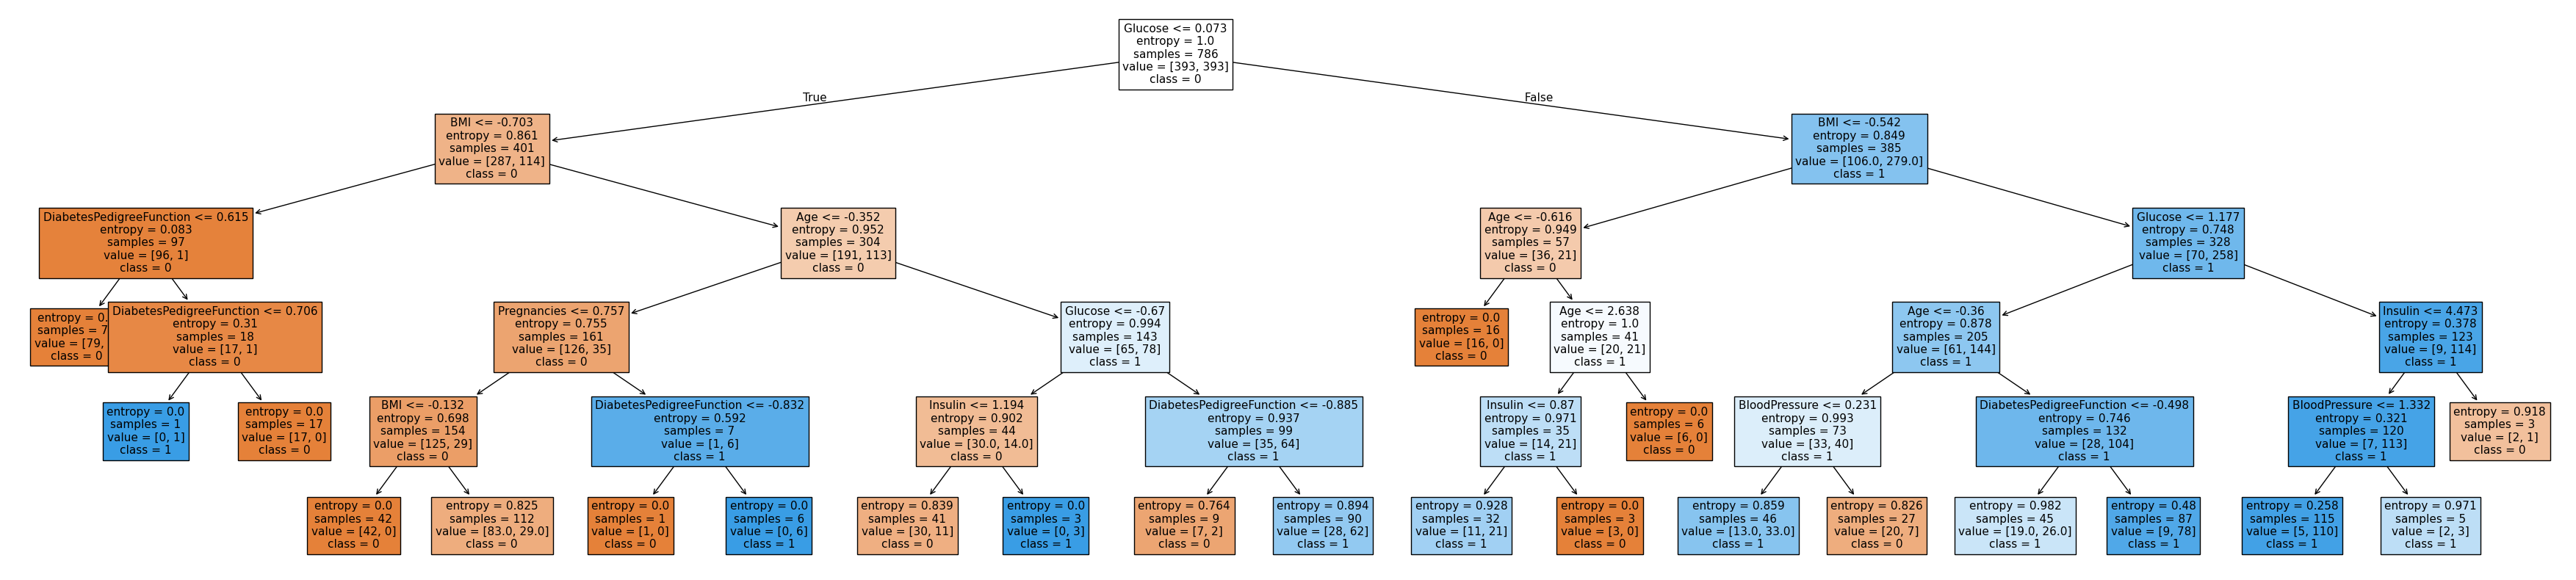

In [51]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(45,10))

fn = x.columns.tolist()


tree.plot_tree(dt, feature_names=fn, class_names=['0','1'], filled=True,fontsize=11)
plt.show()

In [55]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators=20,criterion='gini',max_depth=5,max_features=5)
rfc.fit(x_res,y_res)

RandomForestClassifier(max_depth=5, max_features=5, n_estimators=20)

In [59]:
ypred = rfc.predict(xtest)
ypred

array([1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0,
       0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
      dtype=int64)

In [63]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

print(accuracy_score(ytest,ypred))
print(confusion_matrix(ytest,ypred))
print(classification_report(ytest,ypred))

0.7727272727272727
[[82 25]
 [10 37]]
              precision    recall  f1-score   support

           0       0.89      0.77      0.82       107
           1       0.60      0.79      0.68        47

    accuracy                           0.77       154
   macro avg       0.74      0.78      0.75       154
weighted avg       0.80      0.77      0.78       154



### Random foreset has more accuracy than Decision tree

In [73]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rfc, xtrans, y, cv=5, scoring='accuracy')

print("Cross-Validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

Cross-Validation Accuracy Scores: [0.74675325 0.72727273 0.78571429 0.84313725 0.78431373]
Mean CV Accuracy: 0.7774382480264833


**RandomForestClassifier model performs consistently well across different subsets of the data.**